## Homework 1 - cohort 2021
<br> The goal of this homework is to create a regression model for predicting apartment price (column 'price')

In [1]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/AB_NYC_2019.csv'

In [2]:
!wget $data

--2026-07-08 12:50:18--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/AB_NYC_2019.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 

200 OK
Length: 7077973 (6.8M) [text/plain]
Saving to: ‘AB_NYC_2019.csv’

AB_NYC_2019.csv     100%[===================>]   6.75M  --.-KB/s    in 0.02s   

2026-07-08 12:50:19 (322 MB/s) - ‘AB_NYC_2019.csv’ saved [7077973/7077973]



In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('AB_NYC_2019.csv')

In [2]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.columns  = df.columns.str.lower().str.replace(' ','_')

In [48]:
base = df.dtypes[df.dtypes != 'str'].keys().values.tolist()
base

['id',
 'host_id',
 'latitude',
 'longitude',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [57]:
# base.remove('id')
# base.remove('host_id')
base

['latitude',
 'longitude',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

<Axes: xlabel='price', ylabel='Count'>

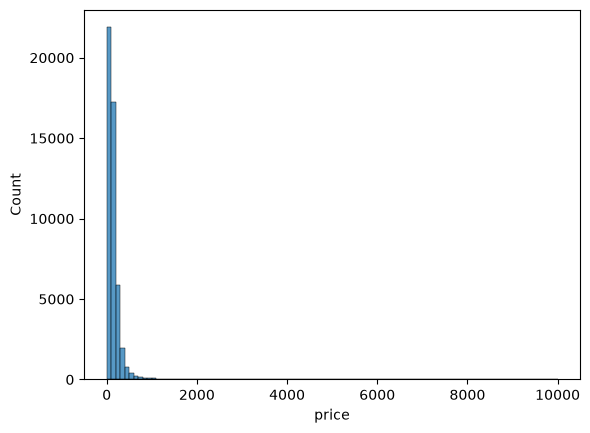

In [8]:
import seaborn as sns
sns.histplot(df['price'], bins = 100)

Q1. features with missing values?

In [10]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Q2. What's the median (50% percentile) for variable 'minimum_nights'

In [12]:
df['minimum_nights'].median()

np.float64(3.0)

In [59]:
df['minimum_nights'].mean()

np.float64(7.029962163820431)

In [19]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = len(df)
idx = np.arange(n)
np.random.shuffle(idx)
idx

array([  879, 44383, 15394, ..., 38158,   860, 15795], shape=(48895,))

In [21]:
df = df.iloc[idx]
df.reset_index(drop=True)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,9297852,Cozy Loft Apartment in Bushwick,48261452,Carolina,Brooklyn,Bushwick,40.70686,-73.91961,Entire home/apt,99,30,7,2017-11-26,0.16,1,0
1,18870281,Room in Ditmas Park Brooklyn,131476188,Kylie,Brooklyn,Flatbush,40.64917,-73.96236,Private room,29,3,0,NaN,NaN,1,0
2,24855669,Gorgeous Brooklyn Oasis,187895786,Aziza,Brooklyn,Bedford-Stuyvesant,40.69327,-73.95725,Private room,75,2,0,NaN,NaN,1,87
3,18752307,The Regal Crash Suite,130461656,King,Manhattan,Harlem,40.81372,-73.95612,Entire home/apt,195,1,51,2019-05-22,1.96,1,67
4,53469,cozy studio with parking spot,204539,Mark,Queens,Middle Village,40.71722,-73.87856,Entire home/apt,98,30,33,2015-05-09,0.31,5,240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,12591059,2 Bedroom next to Prospect Park!,68240110,Elizabeth,Brooklyn,Prospect-Lefferts Gardens,40.65785,-73.96068,Entire home/apt,800,1,4,2016-05-22,0.10,1,357
48891,28187614,"Warm, cozy, private entrance with 2 Full bathr...",212899703,Ms. Debra,Queens,Jamaica,40.67956,-73.76621,Entire home/apt,83,3,29,2019-06-23,2.82,3,48
48892,22107189,"Beautiful 2-bdrm top flr of brownstone, sunny",160647707,John,Brooklyn,Bedford-Stuyvesant,40.68518,-73.95328,Entire home/apt,88,3,4,2018-03-31,0.21,1,0
48893,35163692,Massive NYC Getaway 20 mins to time square wit...,264824216,Peter,Manhattan,Harlem,40.82187,-73.95562,Private room,57,1,2,2019-06-22,1.71,3,54


In [22]:
n_train = int(n*0.6)
n_val = int(n*0.2)
n_test = n - n_train - n_val

<Axes: ylabel='Count'>

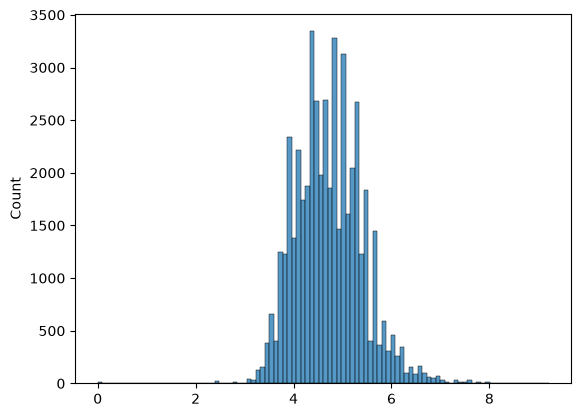

In [37]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

y = df['price'].values
y = np.log1p(y)
sns.histplot(y, bins = 100)

<Axes: xlabel='price', ylabel='Count'>

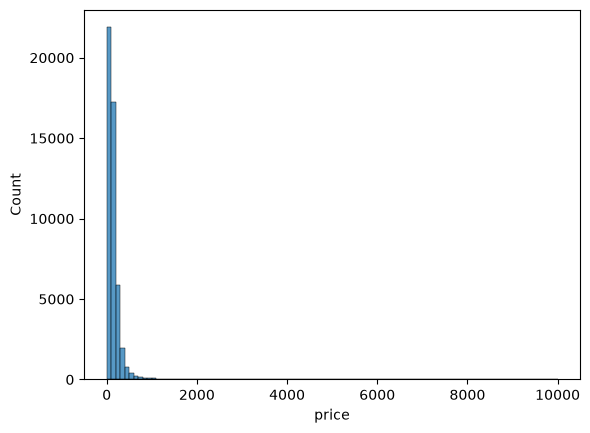

In [34]:
df.reset_index(drop=True, inplace=True)
df['price']
sns.histplot(df['price'], bins = 100)

In [38]:
y_train = y[:n_train]
y_val = y[n_train:n_train+n_val]
y_test = y[n_train+n_val:]

In [68]:
X_train_0 = df_train[base].fillna(0).values
X_train_mean = df_train[base].fillna(df_train[base].mean()).values
X_val_0 = df_val[base].fillna(0).values
X_val_mean = df_val[base].fillna(df_val[base].mean()).values
X_test_0 = df_test[base].fillna(0).values
X_test_mean = df_test[base].fillna(df_test[base].mean()).values


Q3. deal with missing values


In [69]:
def train_linear_regression(X,y):
    X = np.column_stack([np.ones(X.shape[0]),X])
    w = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    w0 = w[0]
    w1 = w[1:]
    return w0,w1


In [82]:
w0,w1 = train_linear_regression(X_train_0,y_train)
w0_mean,w1_mean = train_linear_regression(X_train_mean,y_train)
y_pred_0 = w0 + X_train_0.dot(w1)
y_pred_mean = w0_mean + X_train_mean.dot(w1_mean)


In [72]:
def rmse(y, y_pred):
    error = y - y_pred
    mse = (error **2).mean()
    return np.sqrt(mse)

In [83]:
rmse_0 = rmse(y_train, y_pred_0)
round(rmse_0,5)

np.float64(0.49661)

In [84]:
rmse_mean = rmse(y_train, y_pred_mean)
round(rmse_mean,5)

np.float64(0.49658)

Q4. train a regularized linear regression

In [91]:
def train_linear_regression_reg(X,y,r = 0):
    X = np.column_stack([np.ones(X.shape[0]),X])
    XTX = X.T.dot(X)
    reg = np.eye(XTX.shape[0])
    XTX = XTX + r*reg
    w = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w[0], w[1:]

In [ ]:
r_values = [0,0.000001,0.0001,0.001,0.01,0.1,1,5,10]
X_train = df_train[base].fillna(0).values
X_val = df_val[base].fillna(0).values
best_rmse = float('inf')
best_r = None
for r in r_values:
    w0,w1 = train_linear_regression_reg(X_train, y_train,r)
    y_pred = w0 + X_val.dot(w1)
    rmse_val = rmse(y_val, y_pred)
    if rmse_val < best_rmse:
        best_rmse = rmse_val
        best_r = r
print('Best r:', best_r)


(29337, 8) (9779, 8)
Best r: 0
